
# Lab_5: FEM 1D

### Exercise 1: solve the EDO

Use FEM to solve the next EDO (use the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
\dfrac{d^2y}{dx^2}=-xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general script to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(2-x)-x
\end{equation}

1. **Discretización del Dominio:**
El código divide el intervalo $[0, 1]$ en $N+1$ elementos usando $N+2$ nodos. Los $N$ nodos internos son las incógnitas del sistema, mientras que los extremos [a,b] están fijos por las condiciones de Dirichlet.

2. **Construcción de la Matriz de Rigidez ($A$):**
Se basa en la forma débil de la ecuación. Al usar funciones base lineales ($\phi_i$, conocidas como "funciones sombrero"), la segunda derivada se transforma en una matriz tridiagonal:Diagonal: Representa la interacción del nodo consigo mismo en sus dos elementos adyacentes ($1/h_i + 1/h_{i+1}$).Fuera de la diagonal: Representa la interacción con los nodos vecinos.

3. **Vector de Carga o Término Fuente ($rh\_s$):**
Dado que el término forzante es $-xe^x$, el código proyecta esta función sobre las funciones base:$$b_i = \int f(x)\phi_i(x) dx$$Para mayor precisión, utiliza integración numérica (np.trapz) en cada tramo de la función sombrero (ascendente y descendente), lo que permite manejar funciones complejas que no se integran fácilmente a mano.

4. **Condiciones de Frontera y Solución:**

    Condiciones de Dirichlet: Como los valores en los extremos ($y(0)$ y $y(1)$) son conocidos, sus contribuciones se pasan al lado derecho de la ecuación ($rh\_s$) para no alterar el tamaño de la matriz de los nodos internos.
    
    Resolución: El problema se reduce a un sistema de ecuaciones lineales $A\mathbf{u} = \mathbf{f}$, resuelto de forma eficiente con np.linalg.solve.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

/tmp/ipykernel_6395/540630905.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(f(xL) * phiL, xL) +
/tmp/ipykernel_6395/540630905.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(f(xR) * phiR, xR)


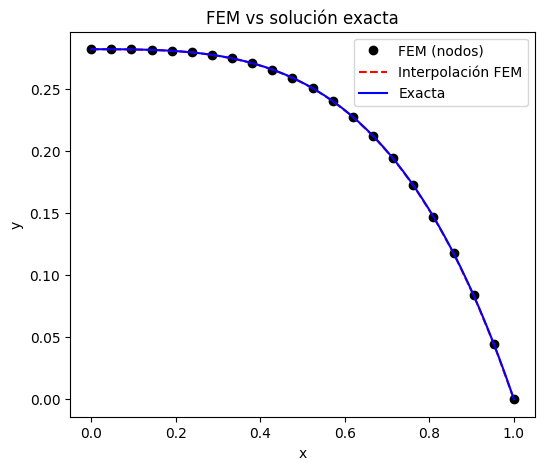

In [ ]:
# dominio de trabajo (simplicidad)
a, b = 0.0, 1.0
N = 20

# malla uniforme
nodes = np.linspace(a, b, N + 2)
h = np.diff(nodes)

# nodos internos
x_int = nodes[1:-1]

# matriz de rigidez
A = np.zeros((N, N))

for i in range(N):
    A[i, i] = 1/h[i] + 1/h[i+1]
    if i > 0:
        A[i, i-1] = -1/h[i]
    if i < N-1:
        A[i, i+1] = -1/h[i+1]

# término fuente
def f(x):
    return x * np.exp(x)

rh_s = np.zeros(N)

# integración del lado derecho de la ecuacion
nq = 30  # puntos de integración
for i in range(N):
    xi = nodes[i]
    xi1 = nodes[i+1]
    xi2 = nodes[i+2]

    # tramo izquierdo [xi, xi1]
    xL = np.linspace(xi, xi1, nq)
    phiL = (xL - xi) / h[i]

    # tramo derecho [xi1, xi2]
    xR = np.linspace(xi1, xi2, nq)
    phiR = (xi2 - xR) / h[i+1]

    rh_s[i] = (
        np.trapz(f(xL) * phiL, xL) +
        np.trapz(f(xR) * phiR, xR)
    )

#condiciones de frontera
Ua = 3 - np.exp(1) #y_a = y(a)
Ub = 0.0 #y_b = y(b)

#reemplazando valores
rh_s[0] += Ua / h[0]
rh_s[-1] += Ub / h[-1]

# solución (puro álgebra lineal)
u_int = np.linalg.solve(A, rh_s)
u = np.concatenate(([Ua], u_int, [Ub]))

# interpolación
x_plot = np.linspace(a, b, 200)
u_interp = np.interp(x_plot, nodes, u)

# solución exacta
def exact(x):
    return 1 - np.exp(1) + np.exp(x)*(2 - x) - x

# graficando ando
plt.figure(figsize=(6,5))
plt.plot(nodes, u, 'ko', label='FEM (nodos)')
plt.plot(x_plot, u_interp, 'r--', label='Interpolación FEM')
plt.plot(x_plot, exact(x_plot), 'b', label='Exacta')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('FEM vs solución exacta')
plt.show()

### Exercise 2: Solve the EDO:  

see pag 36: https://cimec.org.ar/foswiki/pub/Main/Cimec/CursoFEM/cursofem_1.pdf

$-\dfrac{d^2U}{dx^2}(x)=\sin(\pi x)\,,$
in $0\le x\le 1$, with $U(0)=U(1)=0$.

The exact solution is known $U(x)=\dfrac{1}{\pi^2}\sin(\pi x)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

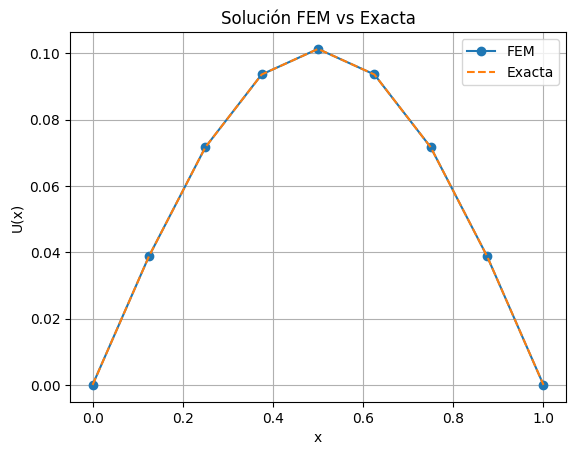

Error máximo: 3.3740907736210597e-06


In [7]:
#Con ayuda del documento del profe
def f(x):
    return np.sin(np.pi * x)

# número de elementos
n = 8
h = 1 / n

# nodos
x = np.linspace(0, 1, n+1)

# matriz global (nodos internos)
A = np.zeros((n-1, n-1))
b = np.zeros(n-1)

# Loop sobre elementos
for k in range(1, n+1):

    xk1 = (k-1)*h
    xk  = k*h

    # matriz de rigidez elemental
    Ak = (1/h) * np.array([[1, -1],
                           [-1, 1]])

    # vector de carga (la fuente)
    bk = np.zeros(2)

    xi = [-1/np.sqrt(3), 1/np.sqrt(3)]
    w  = [1, 1]

    for i in range(2):  # funciones de forma (la base)
        for g in range(2):  # puntos de Gauss

            # mapeo al elemento físico
            xg = ((xk - xk1)/2)*xi[g] + (xk + xk1)/2

            # funciones de forma lineales
            if i == 0:
                phi = (xk - xg)/h
            else:
                phi = (xg - xk1)/h

            bk[i] += w[g] * f(xg) * phi * (h/2)

    #Ensamblando la matriz de rigidez como en el documento
    if k == 1:
        A[0,0] += Ak[1,1]
        b[0] += bk[1]

    elif k == n:
        A[n-2,n-2] += Ak[0,0]
        b[n-2] += bk[0]

    else:
        A[k-2,k-2] += Ak[0,0]
        A[k-2,k-1] += Ak[0,1]
        A[k-1,k-2] += Ak[1,0]
        A[k-1,k-1] += Ak[1,1]

        b[k-2] += bk[0]
        b[k-1] += bk[1]

# Resolver sistema
U_internal = np.linalg.solve(A, b)

# solución completa (incluye fronteras)
U = np.zeros(n+1)
U[1:n] = U_internal

# solución exacta
U_exact = (1/np.pi**2) * np.sin(np.pi * x)


# Gráficando ando
plt.figure()
plt.plot(x, U, 'o-', label='FEM')
plt.plot(x, U_exact, '--', label='Exacta')
plt.legend()
plt.grid()
plt.title("Solución FEM vs Exacta")
plt.xlabel("x")
plt.ylabel("U(x)")
plt.show()

# Error
error = np.linalg.norm(np.abs(U - U_exact)) #Con la que nos enseño el profe
print("Error máximo:", error)